# Statistical Arbitrage - Results and Analysis

This notebook visualizes the full pipeline:
**pair selection → Kalman Filter estimation → signal generation → backtest performance**.

All heavy computation runs in `main.py` and the results are loaded from `.parquet` files.
This notebook is purely for exploration and presentation.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.plotting import Plotter
from src.data_loader import DataLoader
from src.half_life import StationarityAnalyzer
from src.kalman_filter import KalmanFilterPairs
from src.strategy import StatArbStrategy
from src.storage import DataStorage

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

These parameters must match the ones used in `main.py` exactly.
Changing them here re-runs only the visualisation steps (KF + signals), not the full scan.

In [13]:
DATA_DIR    = '../data'
TRAIN_START = '2011-01-01'
TRAIN_END   = '2021-12-31'
TEST_START  = '2022-01-01'
TEST_END    = '2024-03-01'

ENTRY_Z   = 1.0
EXIT_Z    = 0.5
INIT_CAP  = 100_000          # total portfolio capital

# Pairs selected by main.py — recomputed via OLS + ADF on training data (2011-01-01 to 2021-12-31)
# Each dict has: pair=(Y, X), p_value, half_life, beta_init
TOP_PAIRS = [
    {"pair": ("AEP",  "MRK"),  "p_value": 0.000009, "half_life": 36.1, "beta_init": 1.1278},
    {"pair": ("CHTR", "NTES"), "p_value": 0.000002, "half_life": 38.2, "beta_init": 6.8515},
    {"pair": ("CRM",  "NEE"),  "p_value": 0.000007, "half_life": 27.9, "beta_init": 3.5046},
    {"pair": ("CRM",  "PGR"),  "p_value": 0.000170, "half_life": 34.8, "beta_init": 2.7139},
    {"pair": ("KO",   "XLU"),  "p_value": 0.000005, "half_life": 27.6, "beta_init": 1.3291},
]

storage = DataStorage(data_dir=DATA_DIR)
print(f"Config loaded. {len(TOP_PAIRS)} pairs defined.")

Config loaded. 5 pairs defined.


---
## Section 1 — Pair Selection & Cointegration

The Engle-Granger two-step procedure identifies pairs whose price spread is stationary:
1. Regress Y on X via OLS to extract the residual spread.
2. Apply the ADF test on the residuals — a low p-value means the spread is mean-reverting.

We further filter by **half-life** (5–25 days) to ensure the mean reversion is fast enough
to be exploitable at daily frequency without excessive transaction cost drag.

In [14]:
# Load training prices
import json, os
with open(os.path.join(DATA_DIR, 'Tickers.json')) as f:
    tickers_cfg = json.load(f)

tickers = tickers_cfg.get('additional_tickers', tickers_cfg['tickers'])

print('Fetching training data...')
raw = yf.download(tickers, start=TRAIN_START, end=TRAIN_END, progress=False)
train_prices = raw['Close'].ffill().dropna(how='all')
available = train_prices.columns[train_prices.notna().sum() > 200].tolist()
print(f'{len(available)} tickers with sufficient data.')

Fetching training data...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ANSS: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found

2 Failed downloads:
['ANSS', 'DFS']: possibly delisted; no timezone found


173 tickers with sufficient data.


In [17]:
# Build p-value matrix for heatmap (subset for readability — first 20 tickers)
HEATMAP_TICKERS = available[:20]
n = len(HEATMAP_TICKERS)
pval_matrix = np.ones((n, n))

for i, j in itertools.combinations(range(n), 2):
    pair_data = train_prices[[HEATMAP_TICKERS[i], HEATMAP_TICKERS[j]]].dropna()
    if len(pair_data) < 200:
        continue
    try:
        res = sm.OLS(pair_data.iloc[:, 0], sm.add_constant(pair_data.iloc[:, 1])).fit()
        _, pval = StationarityAnalyzer.check_stationarity(res.resid)
        pval_matrix[i, j] = pval_matrix[j, i] = pval
    except Exception:
        pass

print('P-value matrix computed.')

P-value matrix computed.


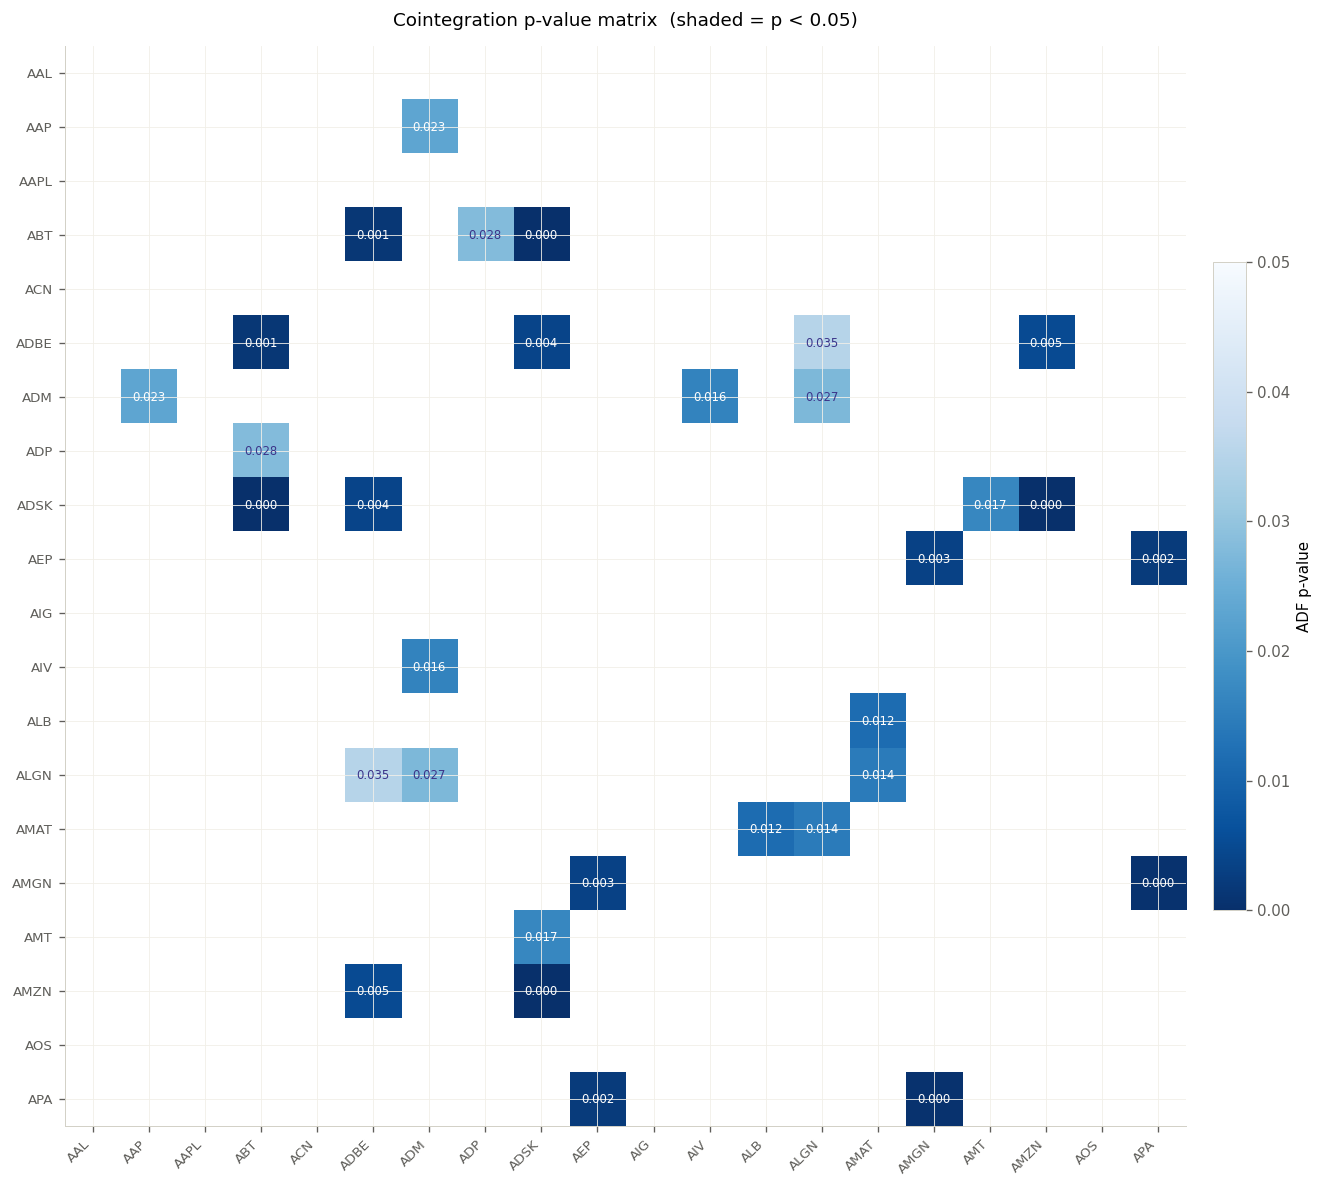

In [18]:
fig = Plotter.cointegration_heatmap(pval_matrix, HEATMAP_TICKERS)
plt.show()

**Reading the heatmap:** Only shaded cells pass the 5% significance threshold.
Darker blue = stronger evidence of cointegration (lower p-value).
Grey cells represent pairs that failed the ADF test.

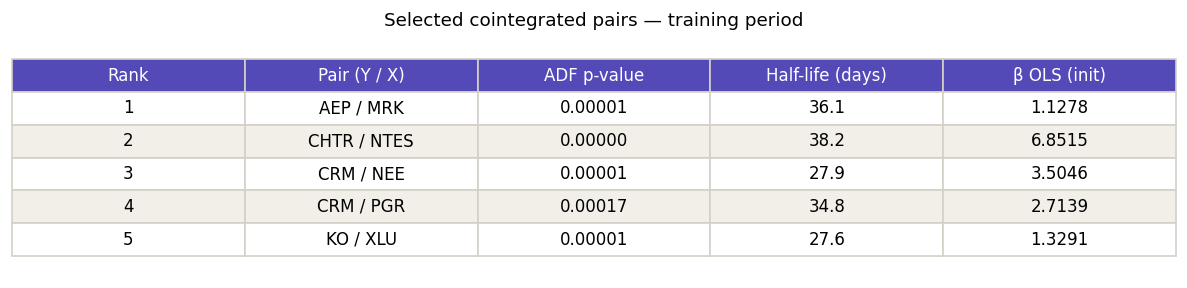

In [19]:
# Selected pairs summary table
if TOP_PAIRS:
    fig = Plotter.pairs_summary_table(TOP_PAIRS)
    plt.show()
else:
    print('Fill in TOP_PAIRS in the Configuration cell, then re-run.')

---
## Section 2 — Kalman Filter & Spread

For each selected pair, the **Kalman Filter** estimates a time-varying hedge ratio β_t.
This is more realistic than a static OLS beta because the true relationship between two stocks
drifts over time as business conditions change.

The **spread** is the KF innovation: `e_t = y_t - (β_t · x_t + α_t)`.  
The **Z-score** normalises this spread using a rolling window equal to the half-life,
producing a stationary signal centred around zero that drives our entry/exit logic.

In [20]:
if not TOP_PAIRS:
    print('Fill in TOP_PAIRS first.')
else:
    # Fetch test prices for all selected tickers
    test_tickers = list({t for p in TOP_PAIRS for t in p['pair']})
    raw_test = yf.download(test_tickers, start=TEST_START, end=TEST_END, progress=False)
    test_prices = raw_test['Close'].ffill().dropna(how='all')
    print(f'Test data loaded: {len(test_prices)} trading days.')

Test data loaded: 542 trading days.


In [21]:
# Compute KF states and Z-scores for each pair — stored for later plots
pair_data_cache = {}  # key = (Y, X)

for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    df_pair = test_prices[[Y, X]].dropna()
    y_arr, x_arr, dates = df_pair[Y].values, df_pair[X].values, df_pair.index

    kf = KalmanFilterPairs(observation_variance=1.0, process_variance=1e-3)
    states, spread = kf.filter(y_arr, x_arr, beta_init=pair_info['beta_init'])
    betas = states[:, 0]

    strategy = StatArbStrategy(entry_z=ENTRY_Z, exit_z=EXIT_Z)
    signals_df = strategy.generate_signals(spread, half_life=pair_info['half_life'])
    signals_df.index = dates

    pair_data_cache[(Y, X)] = dict(
        y_arr=y_arr, x_arr=x_arr, dates=dates,
        betas=betas, spread=spread,
        zscore=signals_df['Z_Score'].values,
        signals_df=signals_df,
    )

print('KF and signals computed for all pairs.')

KF and signals computed for all pairs.



── AEP vs MRK ──


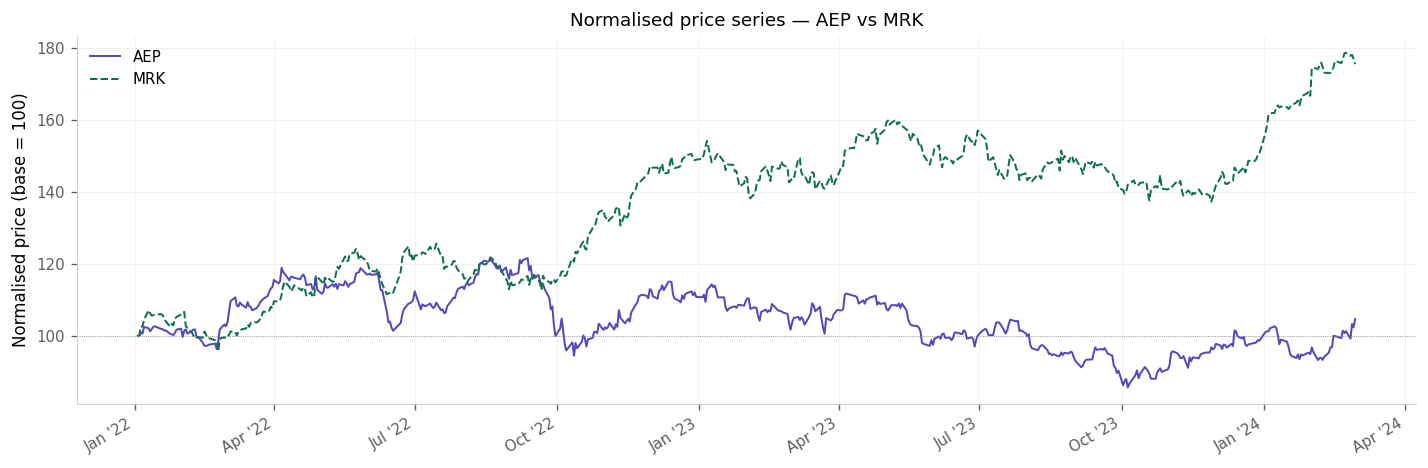

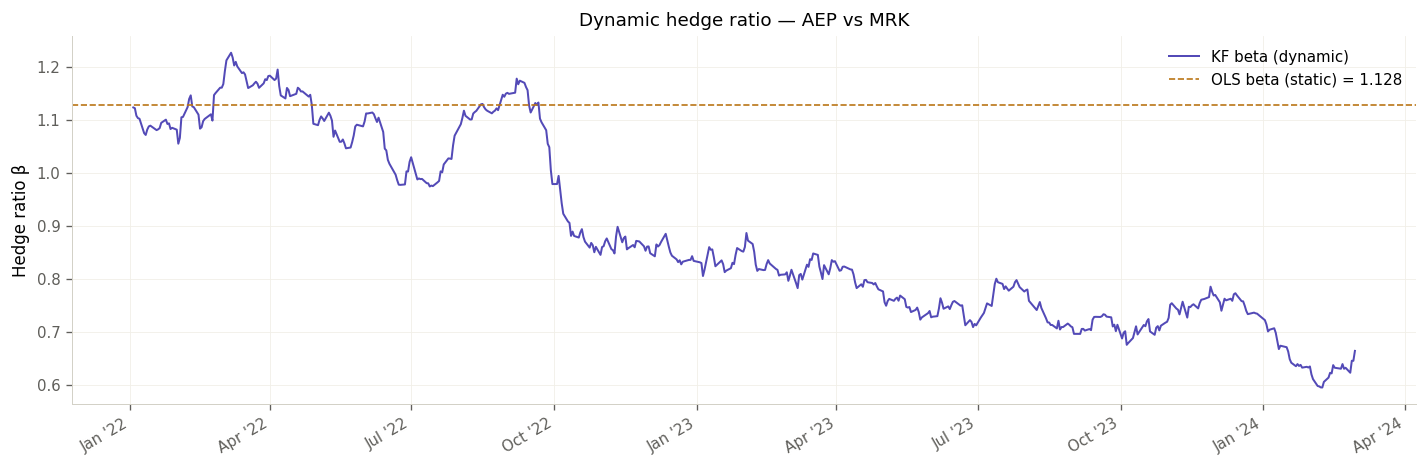

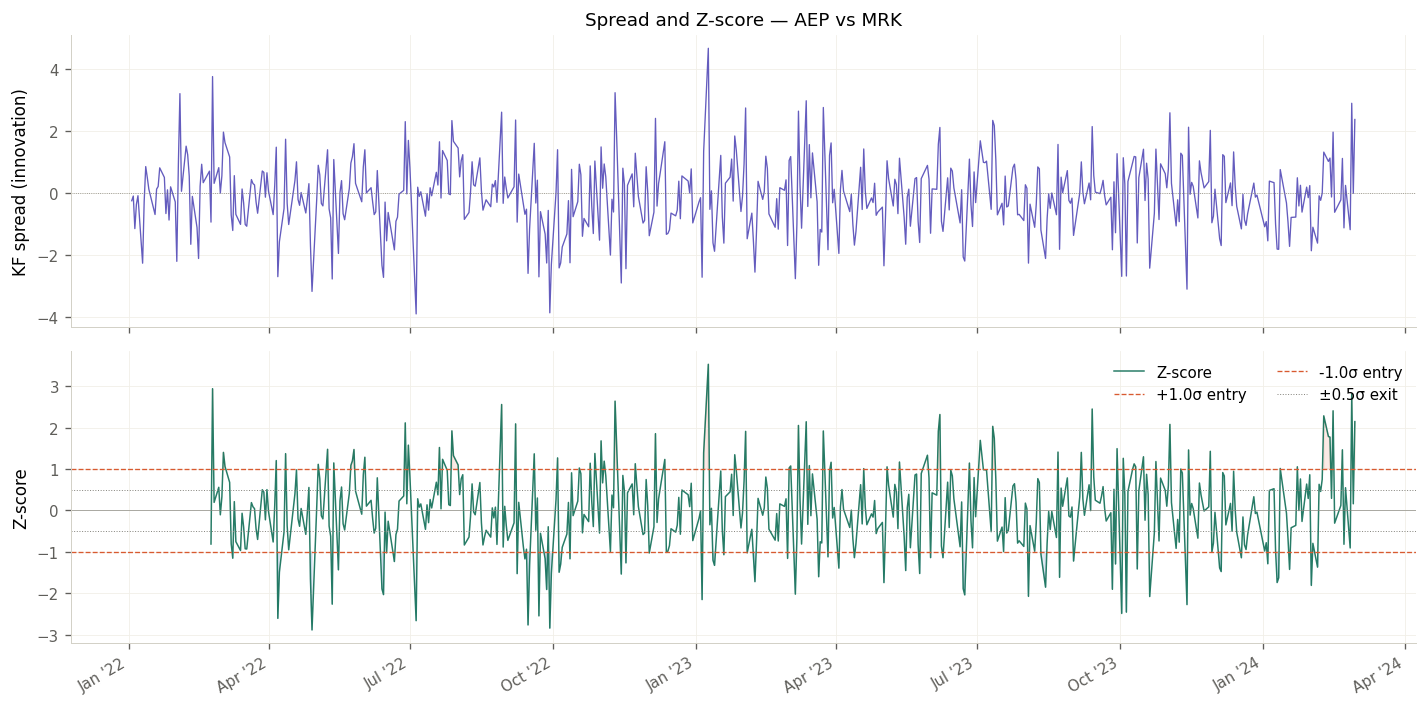


── CHTR vs NTES ──


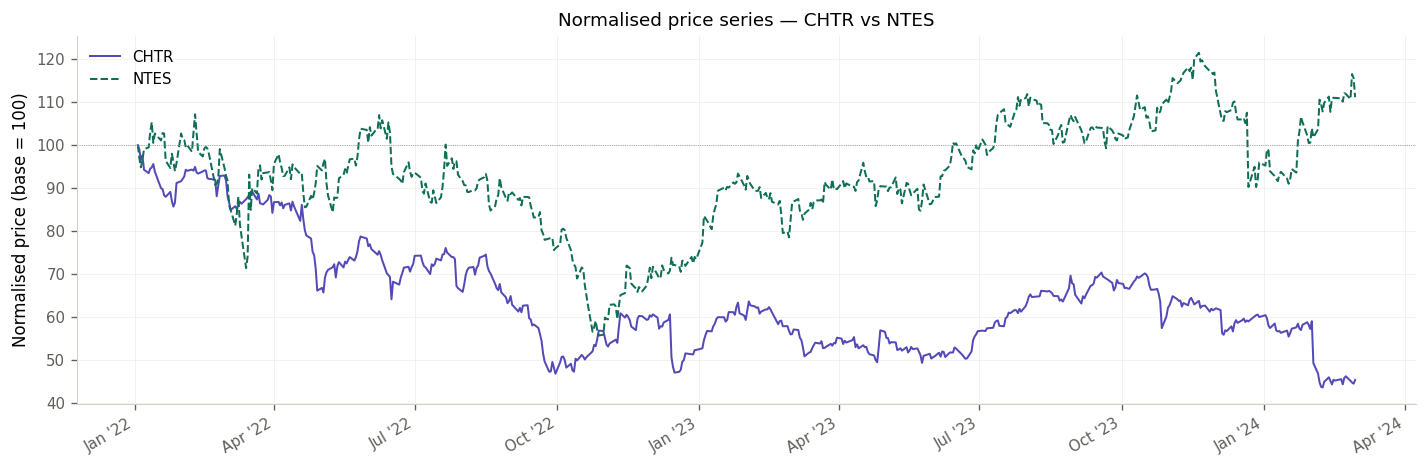

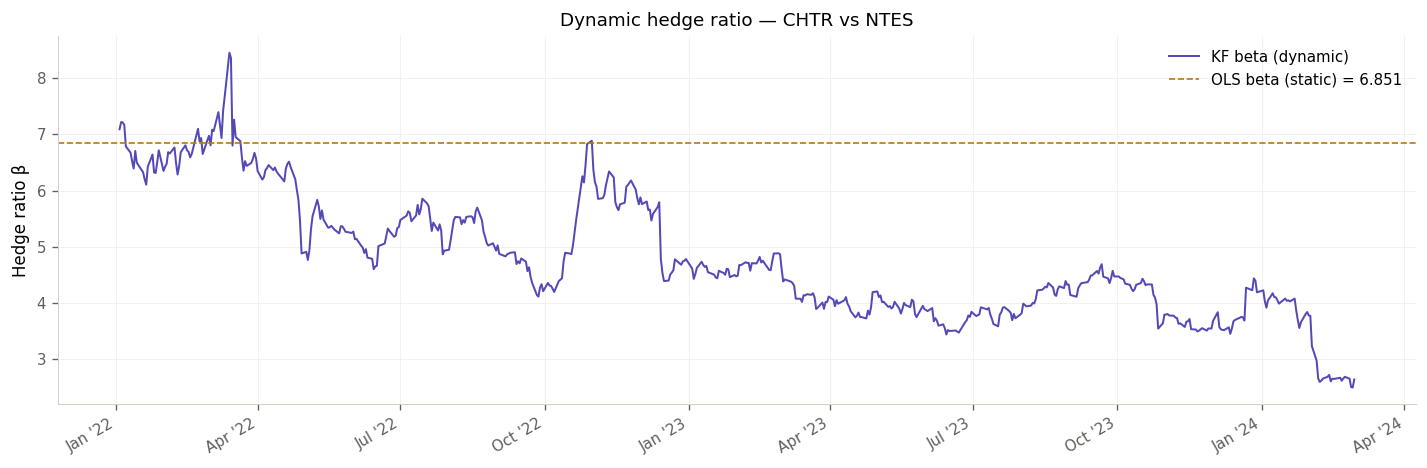

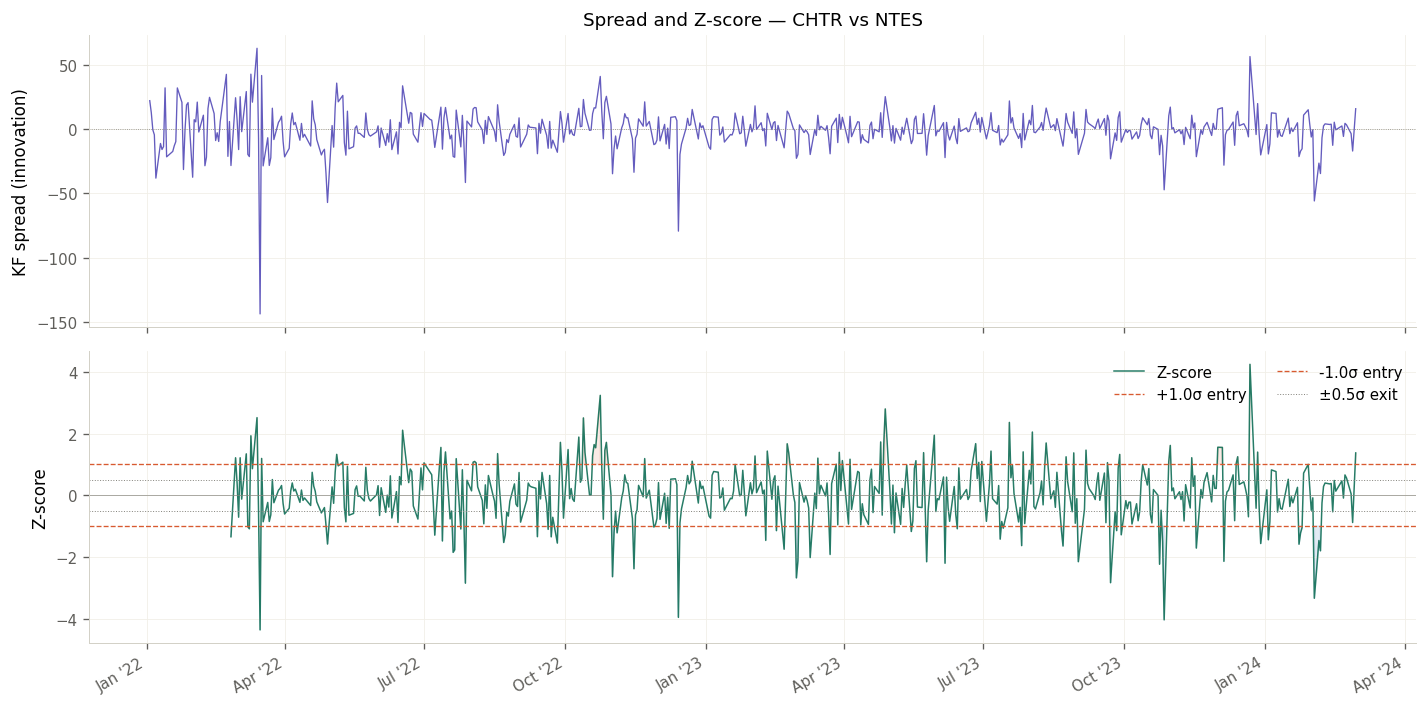


── CRM vs NEE ──


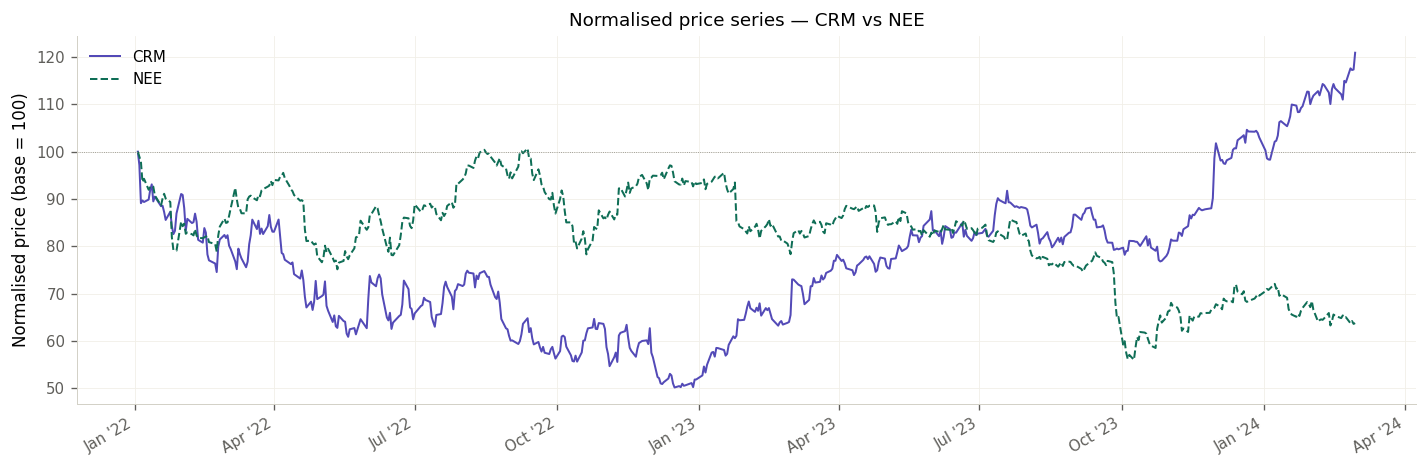

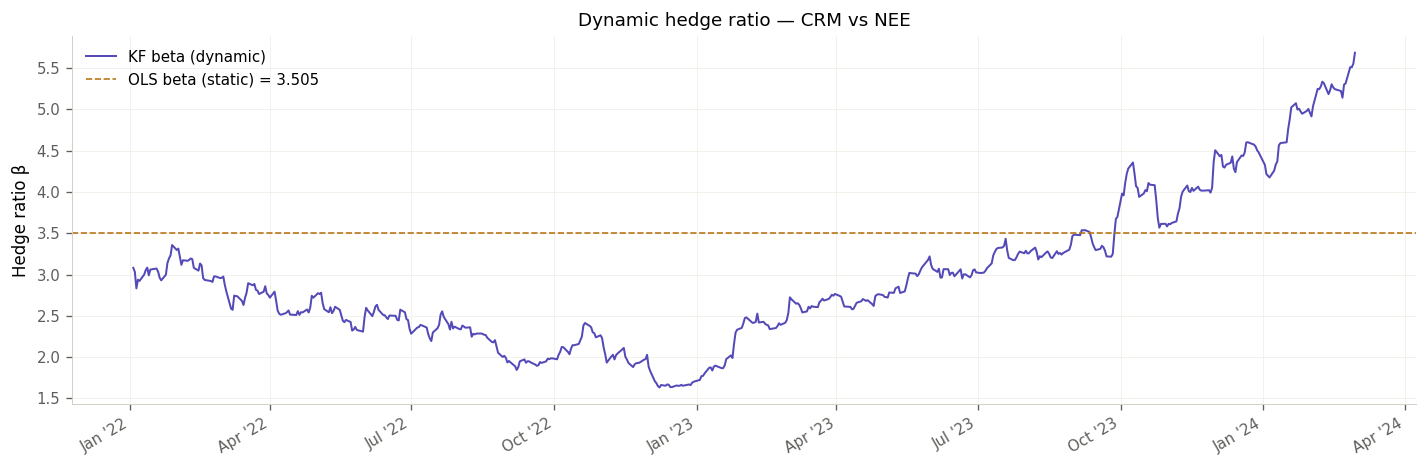

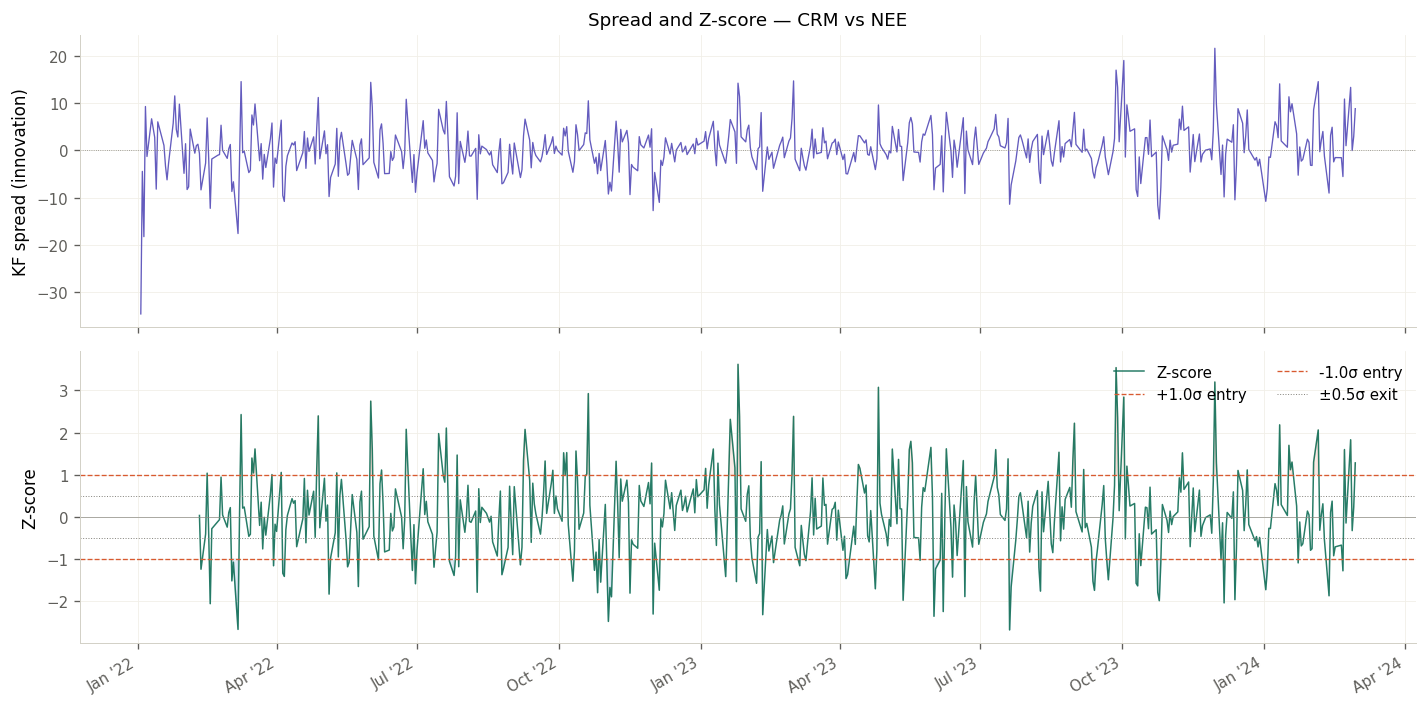


── CRM vs PGR ──


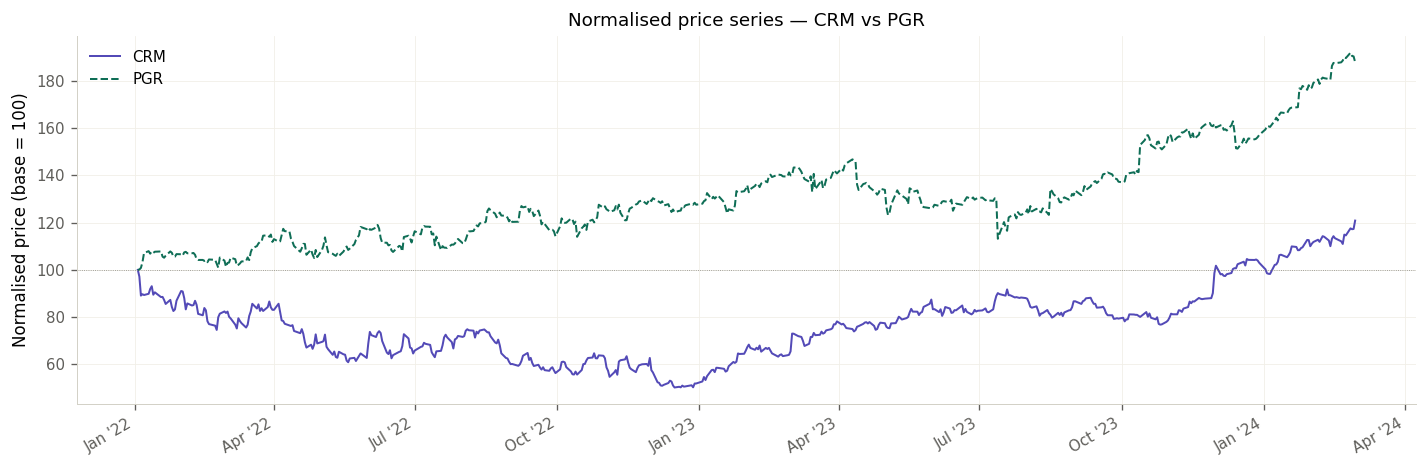

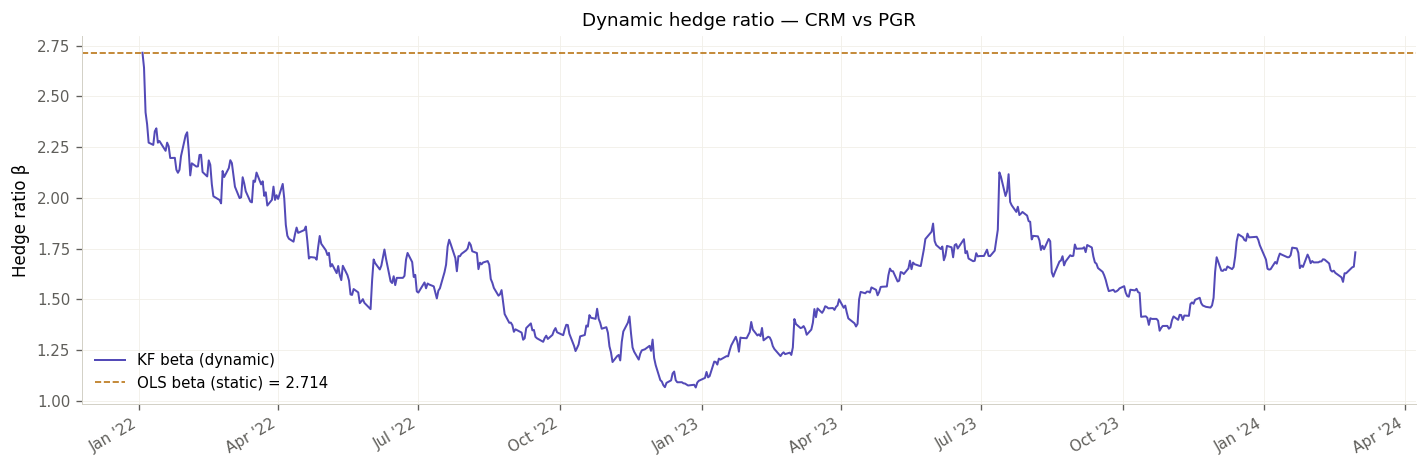

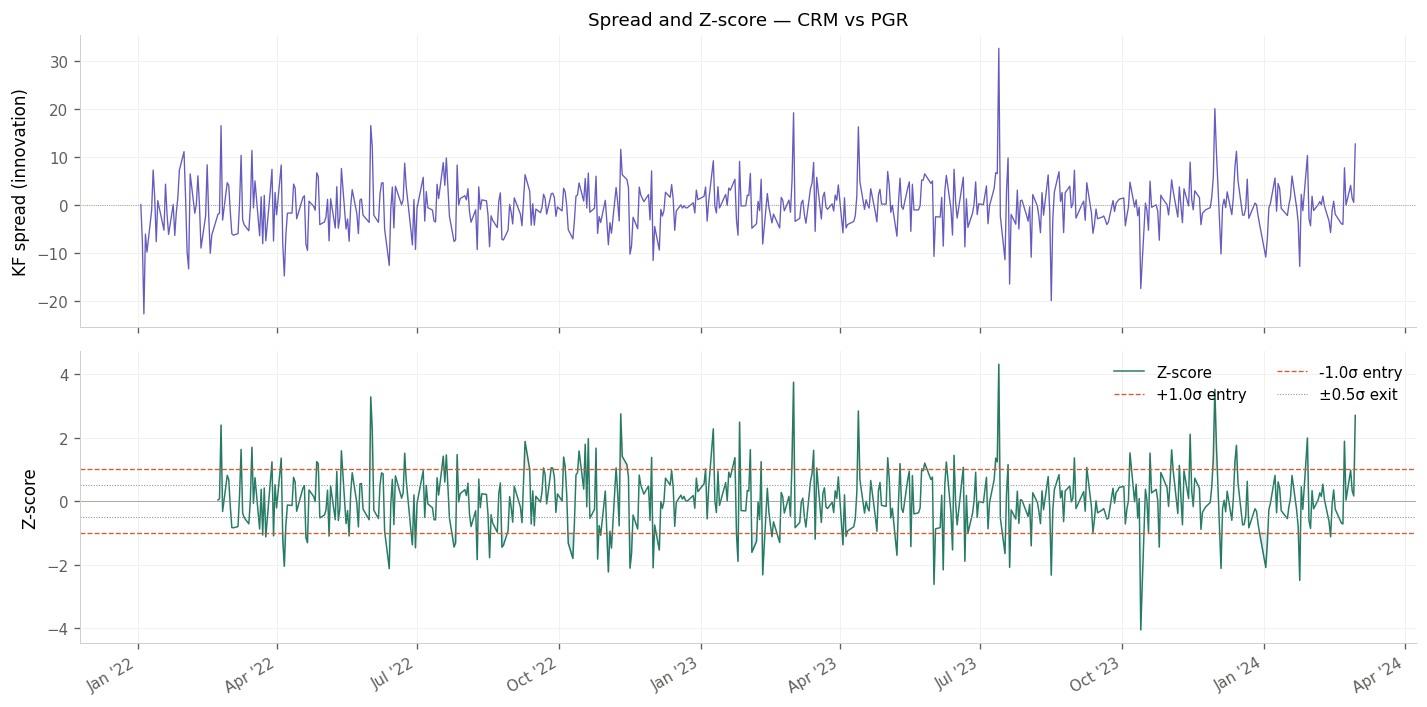


── KO vs XLU ──


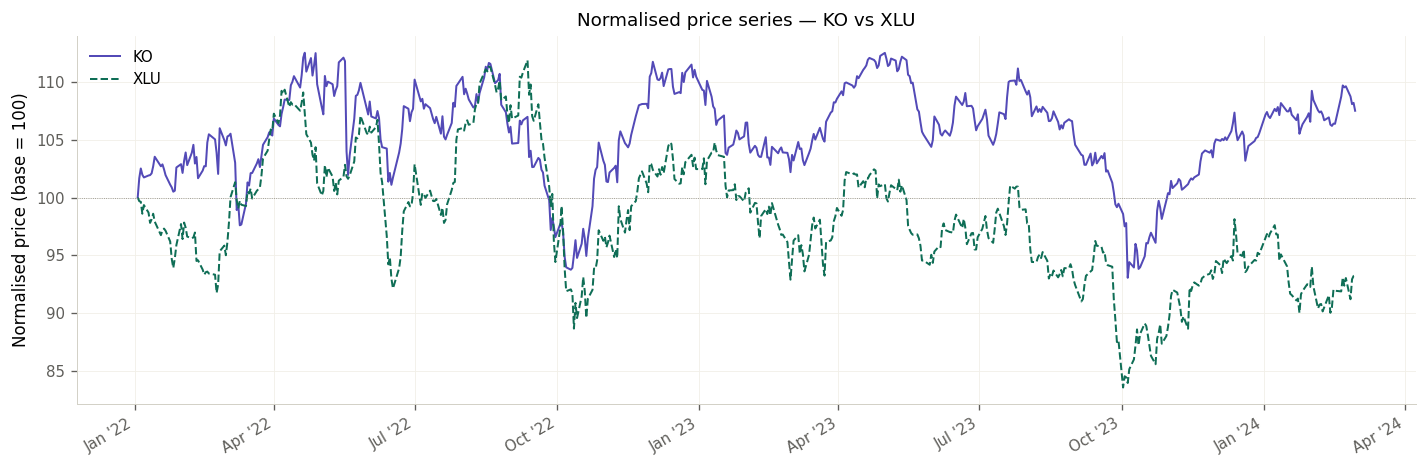

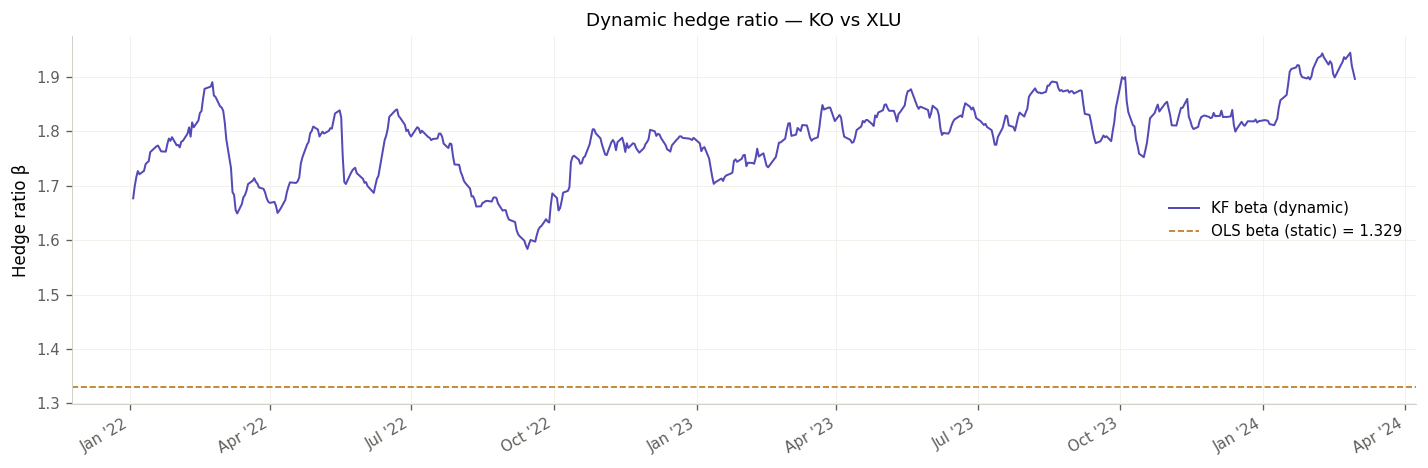

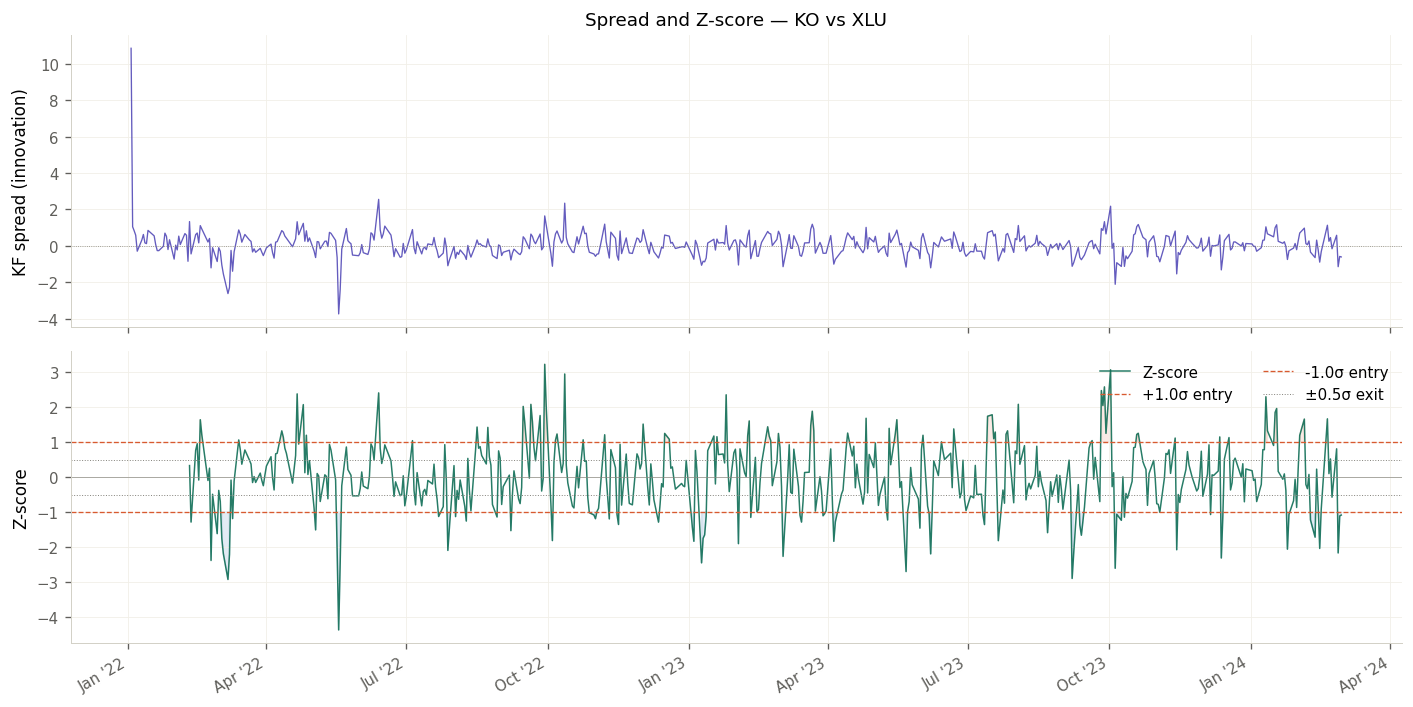

In [22]:
# Plot for each pair
for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    d = pair_data_cache[(Y, X)]

    print(f'\n── {Y} vs {X} ──')

    fig = Plotter.normalized_prices(d['y_arr'], d['x_arr'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.dynamic_beta(d['betas'], pair_info['beta_init'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.spread_and_zscore(
        d['spread'], d['zscore'], d['dates'], Y, X,
        entry_z=ENTRY_Z, exit_z=EXIT_Z
    )
    plt.show()

---
## Section 3 — Strategy & Signal Analysis

Entry and exit rules are based on the Z-score:
- **Long spread** (long Y, short X): when Z-score ≤ −`entry_z`  
- **Short spread** (short Y, long X): when Z-score ≥ +`entry_z`  
- **Exit**: when |Z-score| reverts to ≤ `exit_z`

Position sizing is adaptive — the allocation scales with Z-score magnitude
(0.5× at |z| ∈ (1, 1.5), 0.75× at (1.5, 2), 0.9× at (2, 2.5), 1× at ≥ 2.5).

To prevent look-ahead bias, all signals are shifted by one day before execution:
the signal generated on day t is executed at the open of day t+1.


── AEP vs MRK ──


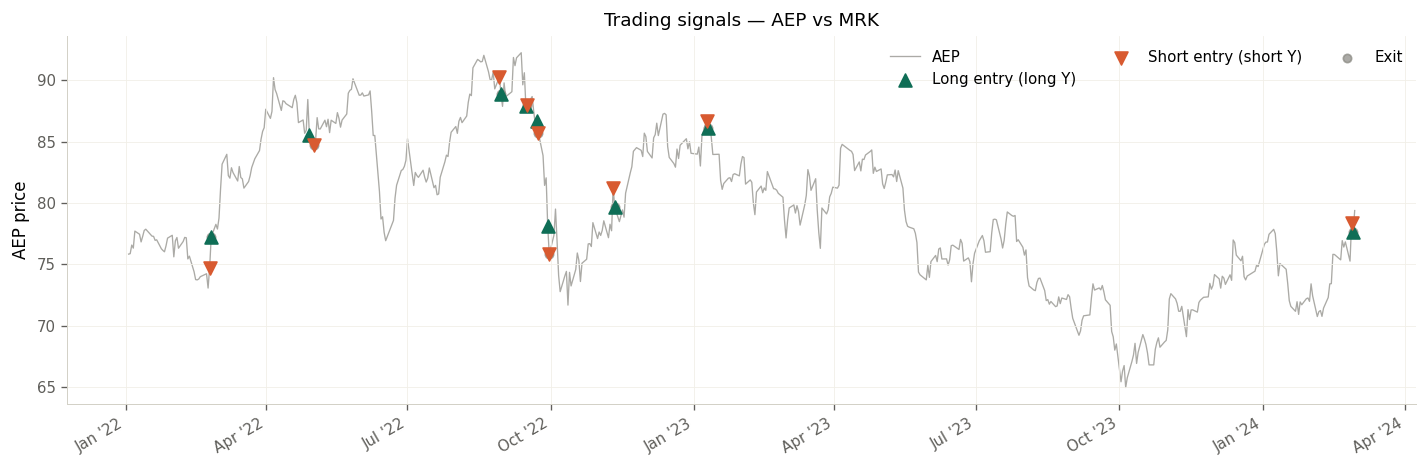

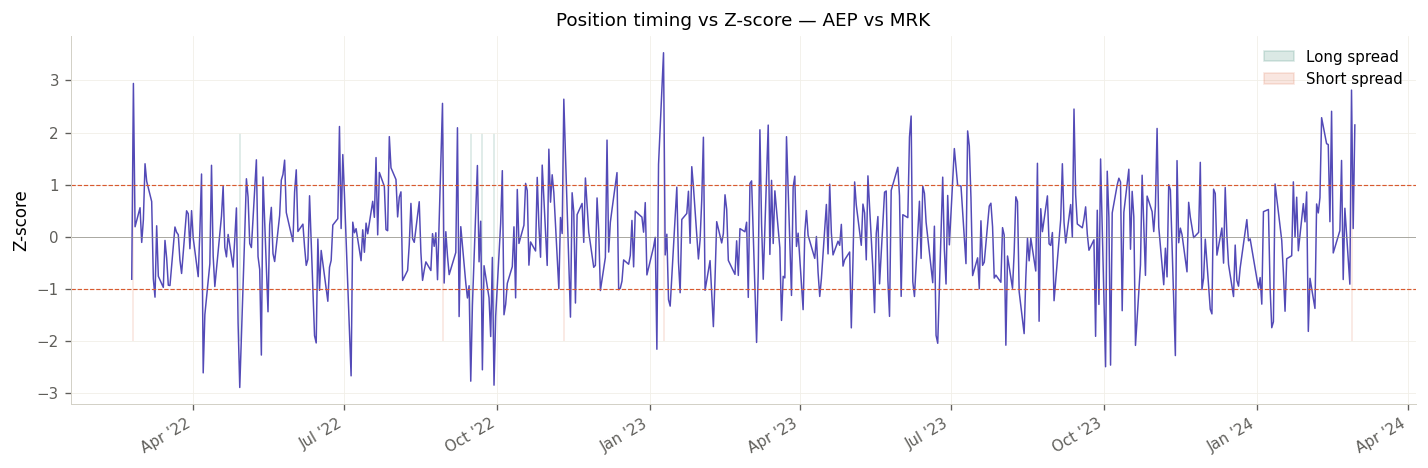


── CHTR vs NTES ──


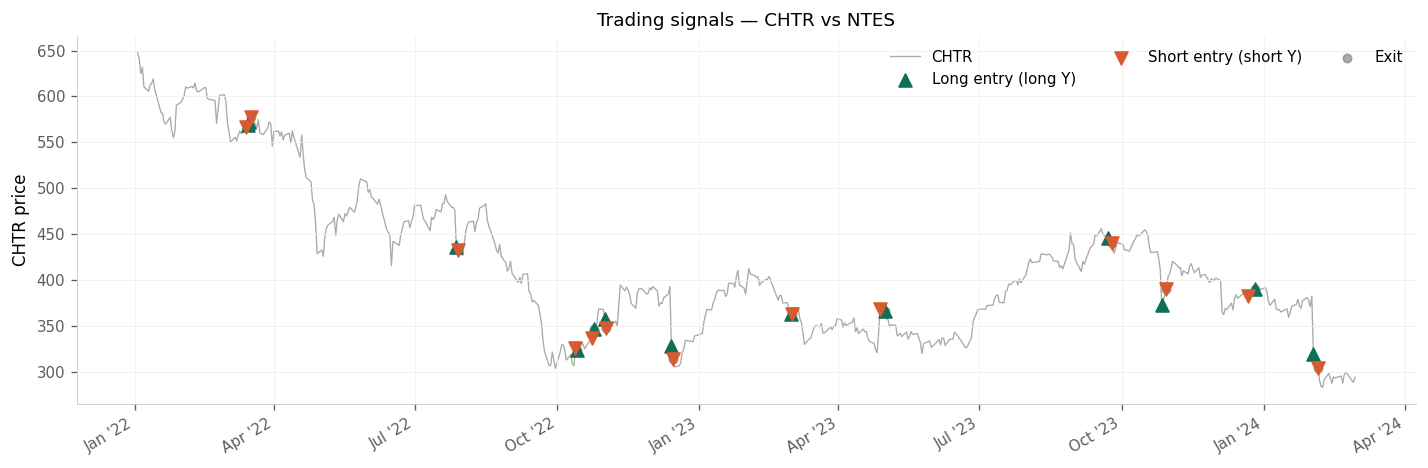

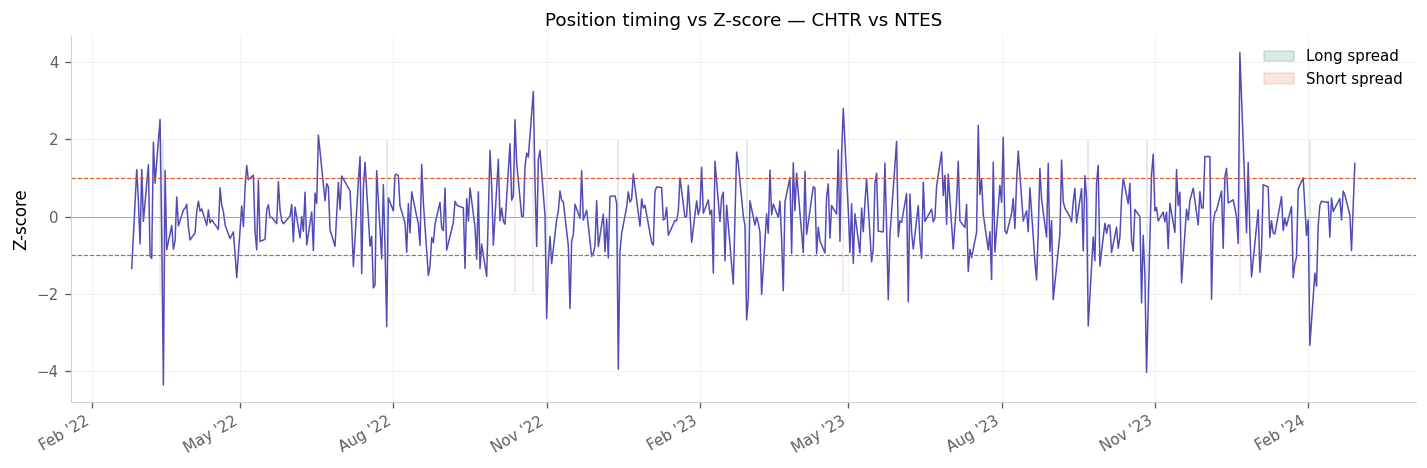


── CRM vs NEE ──


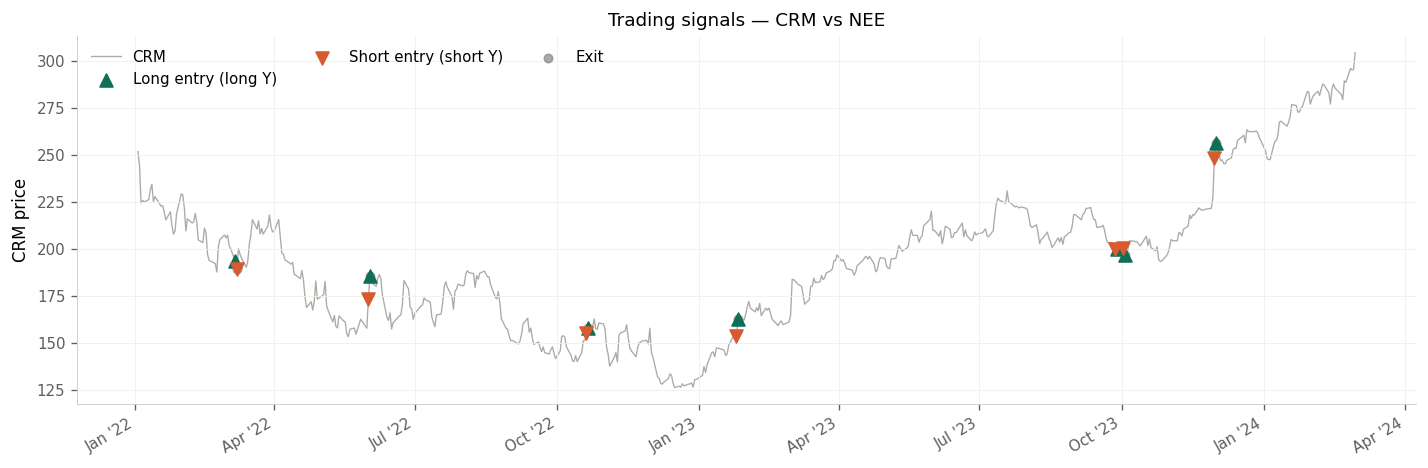

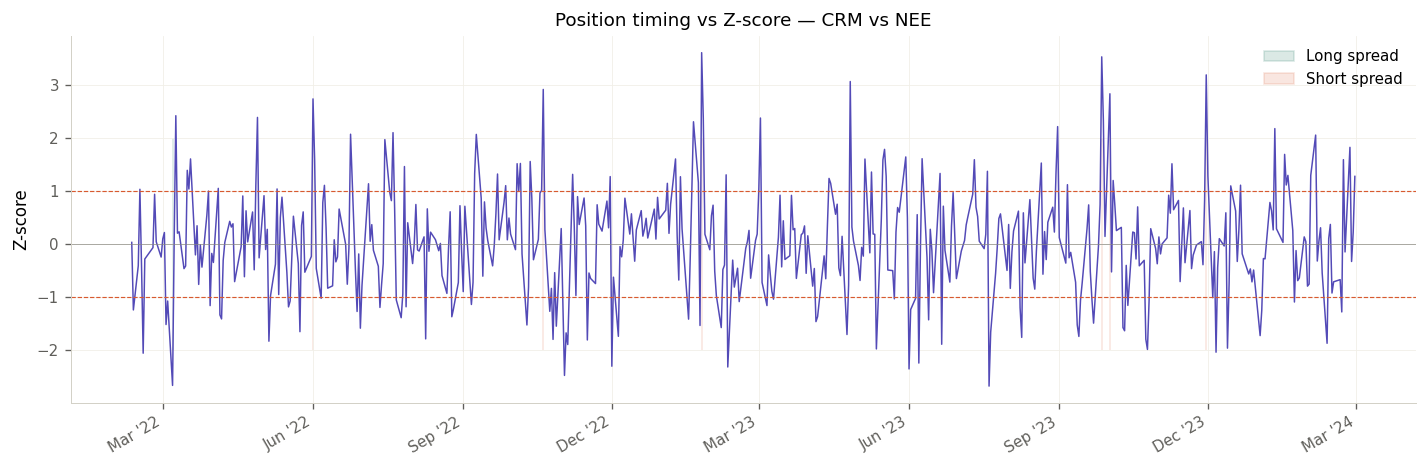


── CRM vs PGR ──


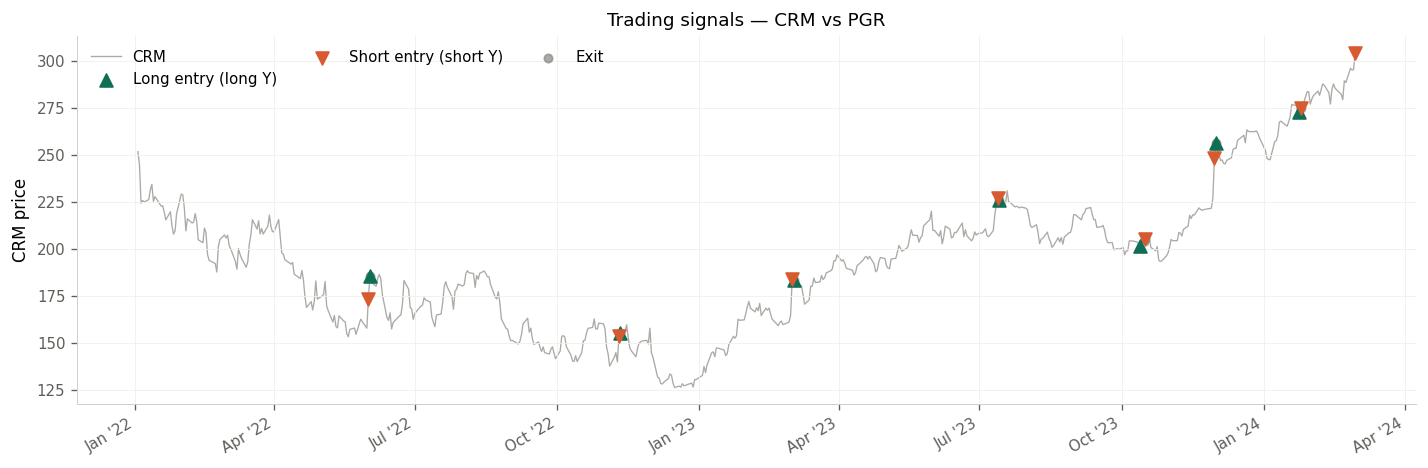

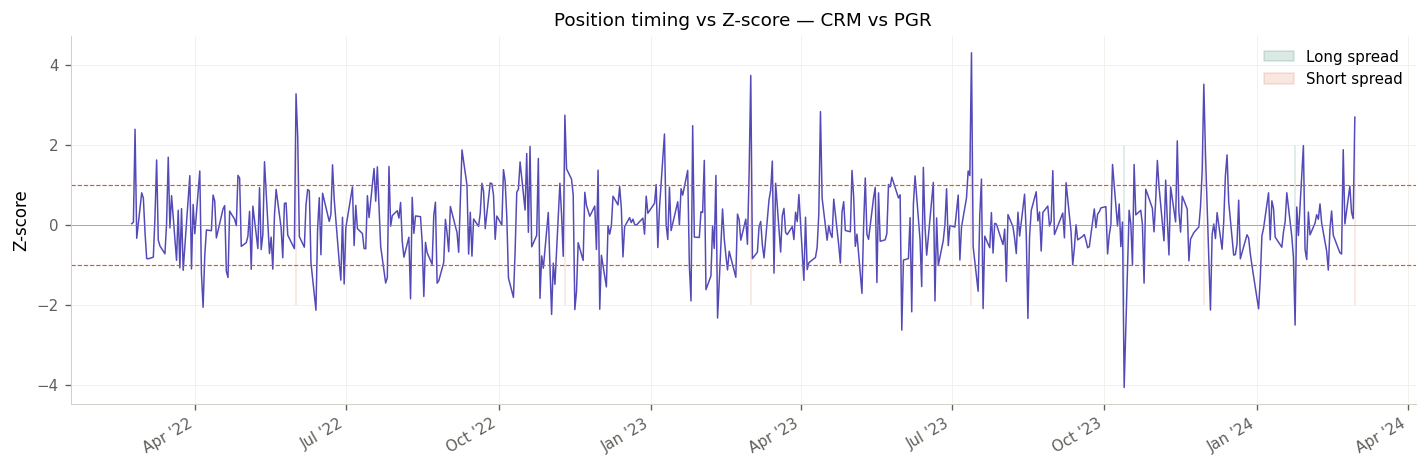


── KO vs XLU ──


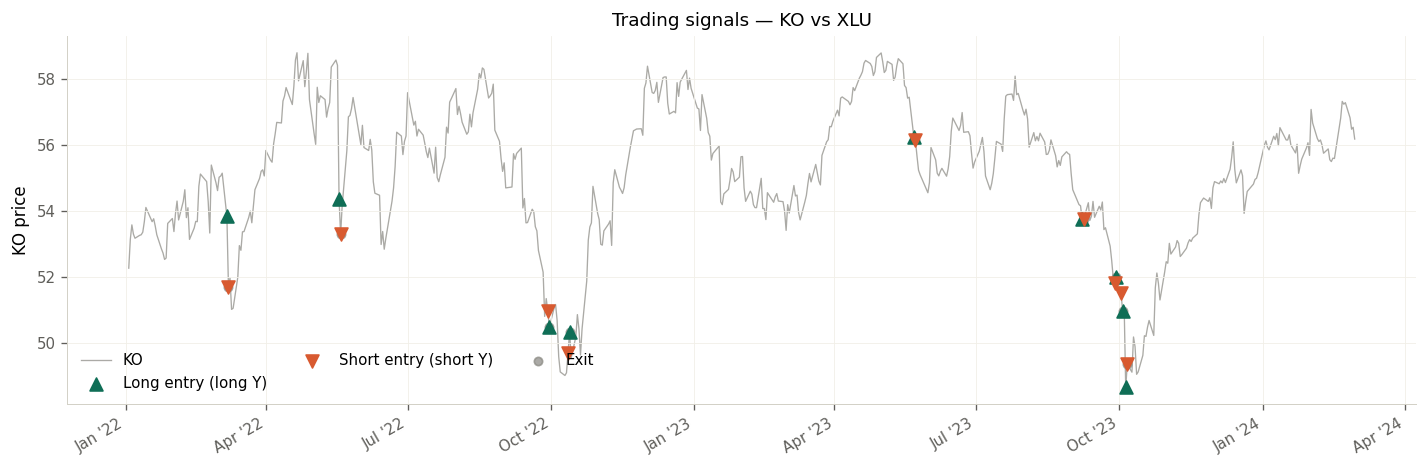

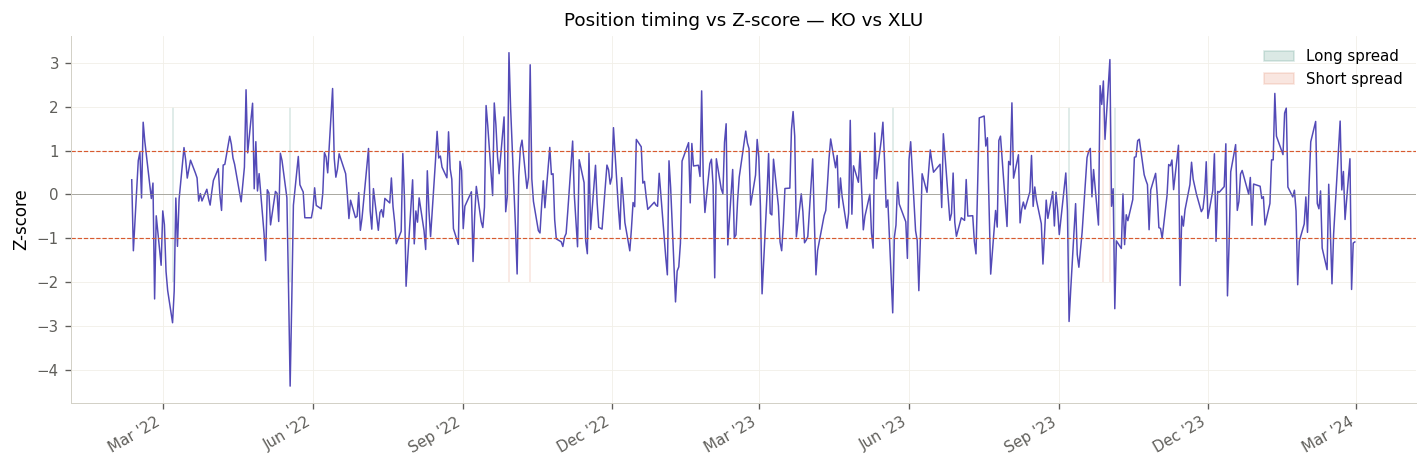

In [23]:
for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    d = pair_data_cache[(Y, X)]
    print(f'\n── {Y} vs {X} ──')

    fig = Plotter.trading_signals(d['y_arr'], d['signals_df'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.position_and_zscore(
        d['zscore'], d['signals_df'], d['dates'], Y, X, entry_z=ENTRY_Z
    )
    plt.show()

---
## Section 4 — Backtest Performance

The backtester simulates dollar-based P&L with:
- **Transaction costs**: 5 bps commission per leg, scaled by liquidity (volume percentile)
- **Dynamic slippage**: proportional to position size relative to daily volume
- **Stop-loss**: −5% per trade; **Take-profit**: +10% per trade
- **Market neutrality**: X leg sized by the dynamic KF beta at execution time

Results are loaded from the `.parquet` files produced by `main.py`.

In [24]:
results_list = []
labels = []

for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    filename = f"backtest_{Y}_{X}".replace('.', '_').replace('^', '')
    try:
        df = storage.load_from_parquet(filename)
        results_list.append(df)
        labels.append(f"{Y}/{X}")
    except FileNotFoundError:
        print(f'  [WARNING] {filename}.parquet not found — run main.py first.')

print(f'{len(results_list)} pair result files loaded.')

[Storage] Data loaded from ../data/backtest_AEP_MRK.parquet
[Storage] Data loaded from ../data/backtest_CHTR_NTES.parquet
[Storage] Data loaded from ../data/backtest_CRM_NEE.parquet
[Storage] Data loaded from ../data/backtest_CRM_PGR.parquet
[Storage] Data loaded from ../data/backtest_KO_XLU.parquet
5 pair result files loaded.


In [25]:
# Load combined portfolio
try:
    portfolio_df = storage.load_from_parquet('portfolio_combined')
    portfolio_equity = portfolio_df['Portfolio_Equity']
    print('Combined portfolio equity loaded.')
except FileNotFoundError:
    portfolio_equity = None
    print('portfolio_combined.parquet not found — run main.py first.')

[Storage] Data loaded from ../data/portfolio_combined.parquet
Combined portfolio equity loaded.


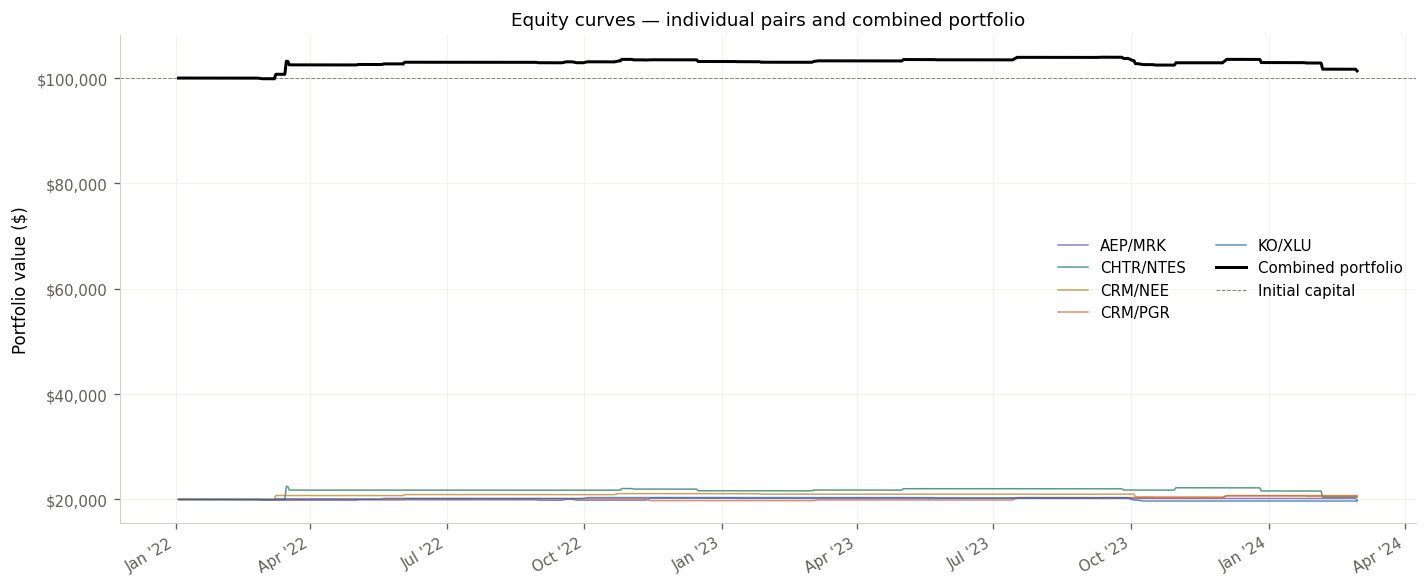

In [26]:
if results_list:
    per_pair_cap = INIT_CAP / len(TOP_PAIRS)

    fig = Plotter.equity_curves(results_list, labels, INIT_CAP, portfolio_equity)
    plt.show()

**Reading the equity curves:** Each coloured line is an individual pair.
The black line is the combined portfolio (sum of all pair equity curves).
Diversification across uncorrelated pairs reduces individual spikes and smooths the curve.

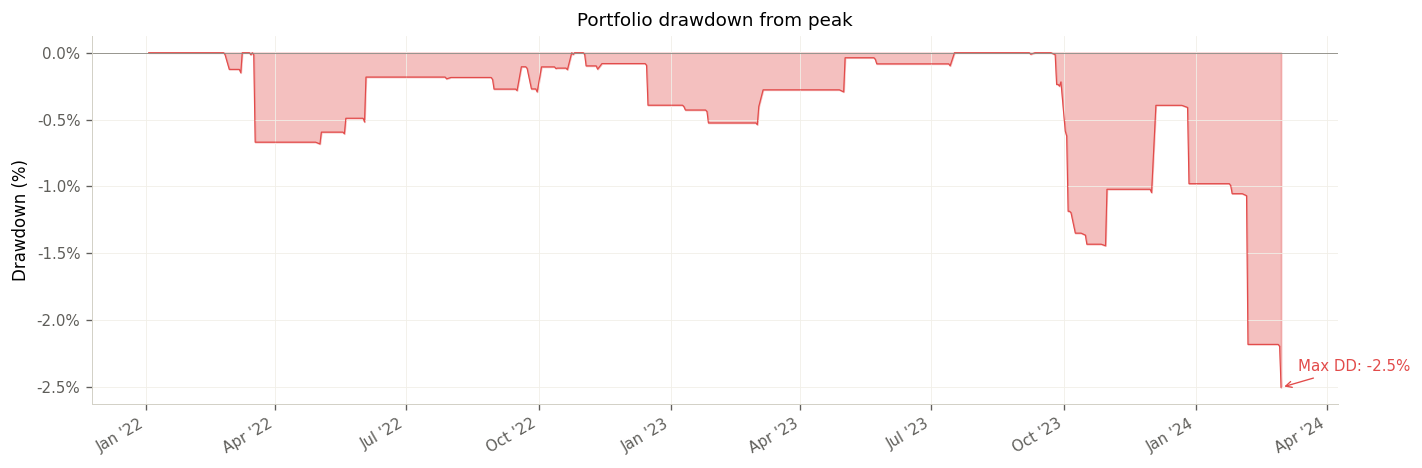

In [27]:
if portfolio_equity is not None:
    fig = Plotter.drawdown_chart(portfolio_equity)
    plt.show()

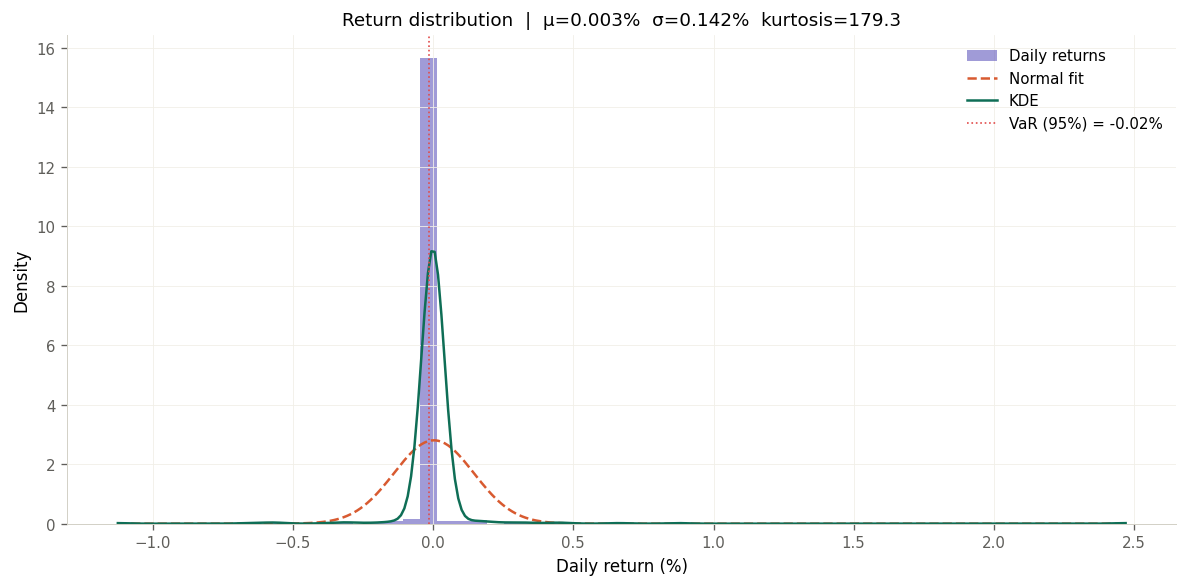

In [28]:
if portfolio_equity is not None:
    fig = Plotter.return_distribution(portfolio_equity)
    plt.show()

**Reading the return distribution:** The gap between the actual histogram and the normal curve
shows **excess kurtosis** (fat tails). StatArb strategies typically have positive skewness
(many small gains) but occasional large losses — the left tail reveals this asymmetry.
The VaR line marks the daily loss level exceeded only 5% of the time.

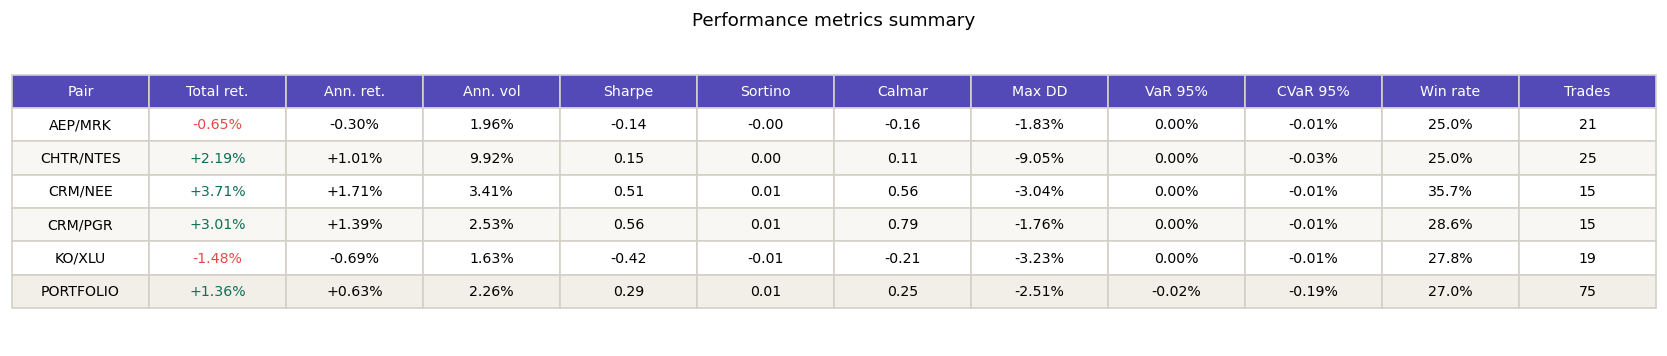

In [29]:
if results_list:
    fig = Plotter.performance_table(
        results_list, labels,
        initial_capital_per_pair=per_pair_cap,
        portfolio_equity=portfolio_equity,
        total_capital=INIT_CAP,
    )
    plt.show()

---
## Summary and Conclusions

| Component | Implementation |
|---|---|
| Cointegration test | Engle-Granger two-step (OLS + ADF on residuals) |
| Hedge ratio estimation | Kalman Filter (streaming), Q/R = 0.001, warm-start from OLS |
| Signal generation | Z-score rolling window = half-life, entry ±1σ, exit ±0.5σ |
| Position sizing | Adaptive 4-tier (0.5× / 0.75× / 0.9× / 1×) by |z| magnitude |
| Execution model | Dollar-based, 1-day delay, 5 bps TC, liquidity-adjusted slippage |
| Risk controls | Stop-loss −5%, take-profit +10% per trade |
| Portfolio | Equal-weight across top N pairs, combined equity curve |

**Limitations to be aware of:**
- Short-selling borrowing costs are not modelled (relevant for illiquid or hard-to-borrow stocks).
- Currency risk is ignored for cross-currency pairs.
- Settlement delays (T+2/T+3) are not explicitly modelled.
- Results depend heavily on the stability of cointegration out-of-sample —  
  pairs that pass the ADF test in-sample may diverge structurally in the test period.